In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cancer_dna_dataset.csv')
df.info()
print(df.describe())
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        108 non-null    object 
 1   DNA_Sequence     108 non-null    object 
 2   Cancer_Status    108 non-null    object 
 3   Sequence_Length  108 non-null    int64  
 4   GC_Content       108 non-null    float64
 5   AT_Content       108 non-null    float64
 6   Kmer_ATG_Count   108 non-null    int64  
 7   Kmer_CGG_Count   108 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 6.9+ KB
       Sequence_Length  GC_Content  AT_Content  Kmer_ATG_Count  Kmer_CGG_Count
count       108.000000  108.000000  108.000000      108.000000      108.000000
mean         22.203704   50.400185   49.599815        0.287037        0.287037
std           1.527072   10.616740   10.616740        0.474606        0.564543
min          20.000000   22.730000   19.050000        0.00

# Histogram Box Plot

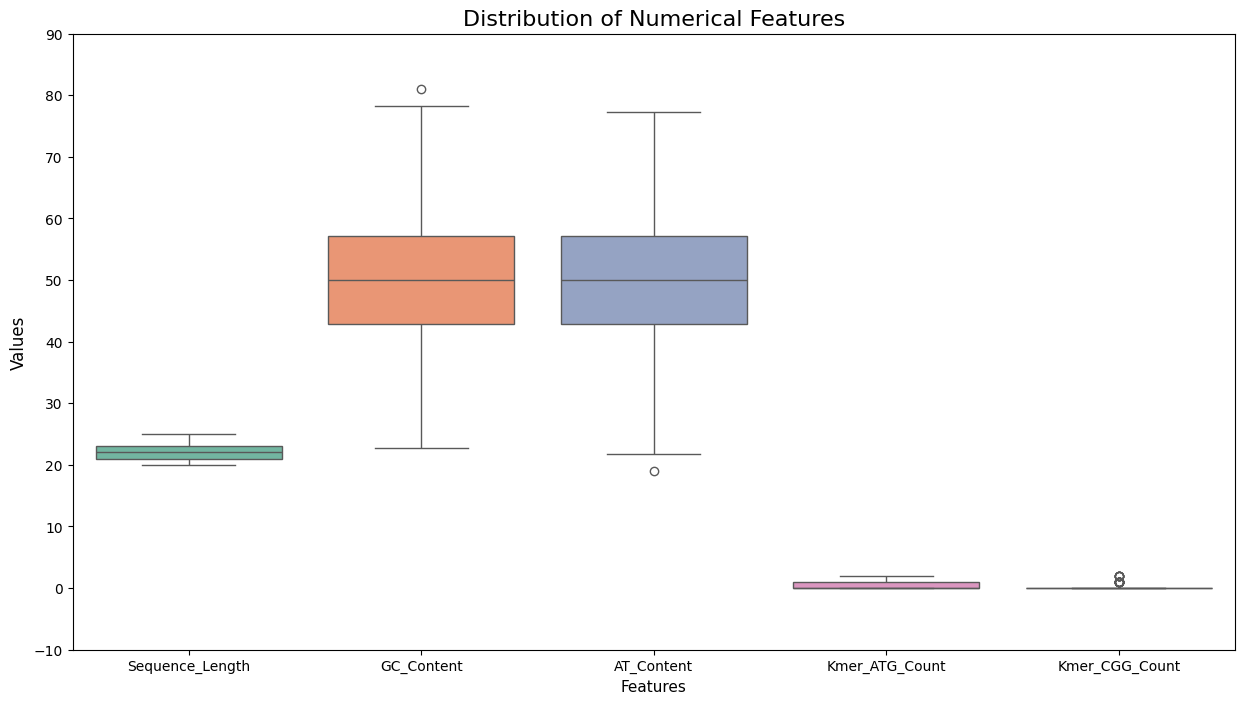

In [36]:
numerical_features = ["Sequence_Length", "GC_Content", "AT_Content",
                     "Kmer_ATG_Count", "Kmer_CGG_Count"]
# Create a boxplot for all numerical features
plt.figure(figsize=(15, 8))  # Set the figure size
sns.boxplot(data=df[numerical_features], palette="Set2")

# Add title and axis labels
plt.title("Distribution of Numerical Features", fontsize=16)
plt.xlabel("Features", fontsize=11)
plt.ylabel("Values", fontsize=12)
plt.yticks(range(-10, 100, 10))
# Display the plot
plt.show()
df["Cancer_Status"] = df["Cancer_Status"].map({"Healthy": 0, "Cancer": 1})

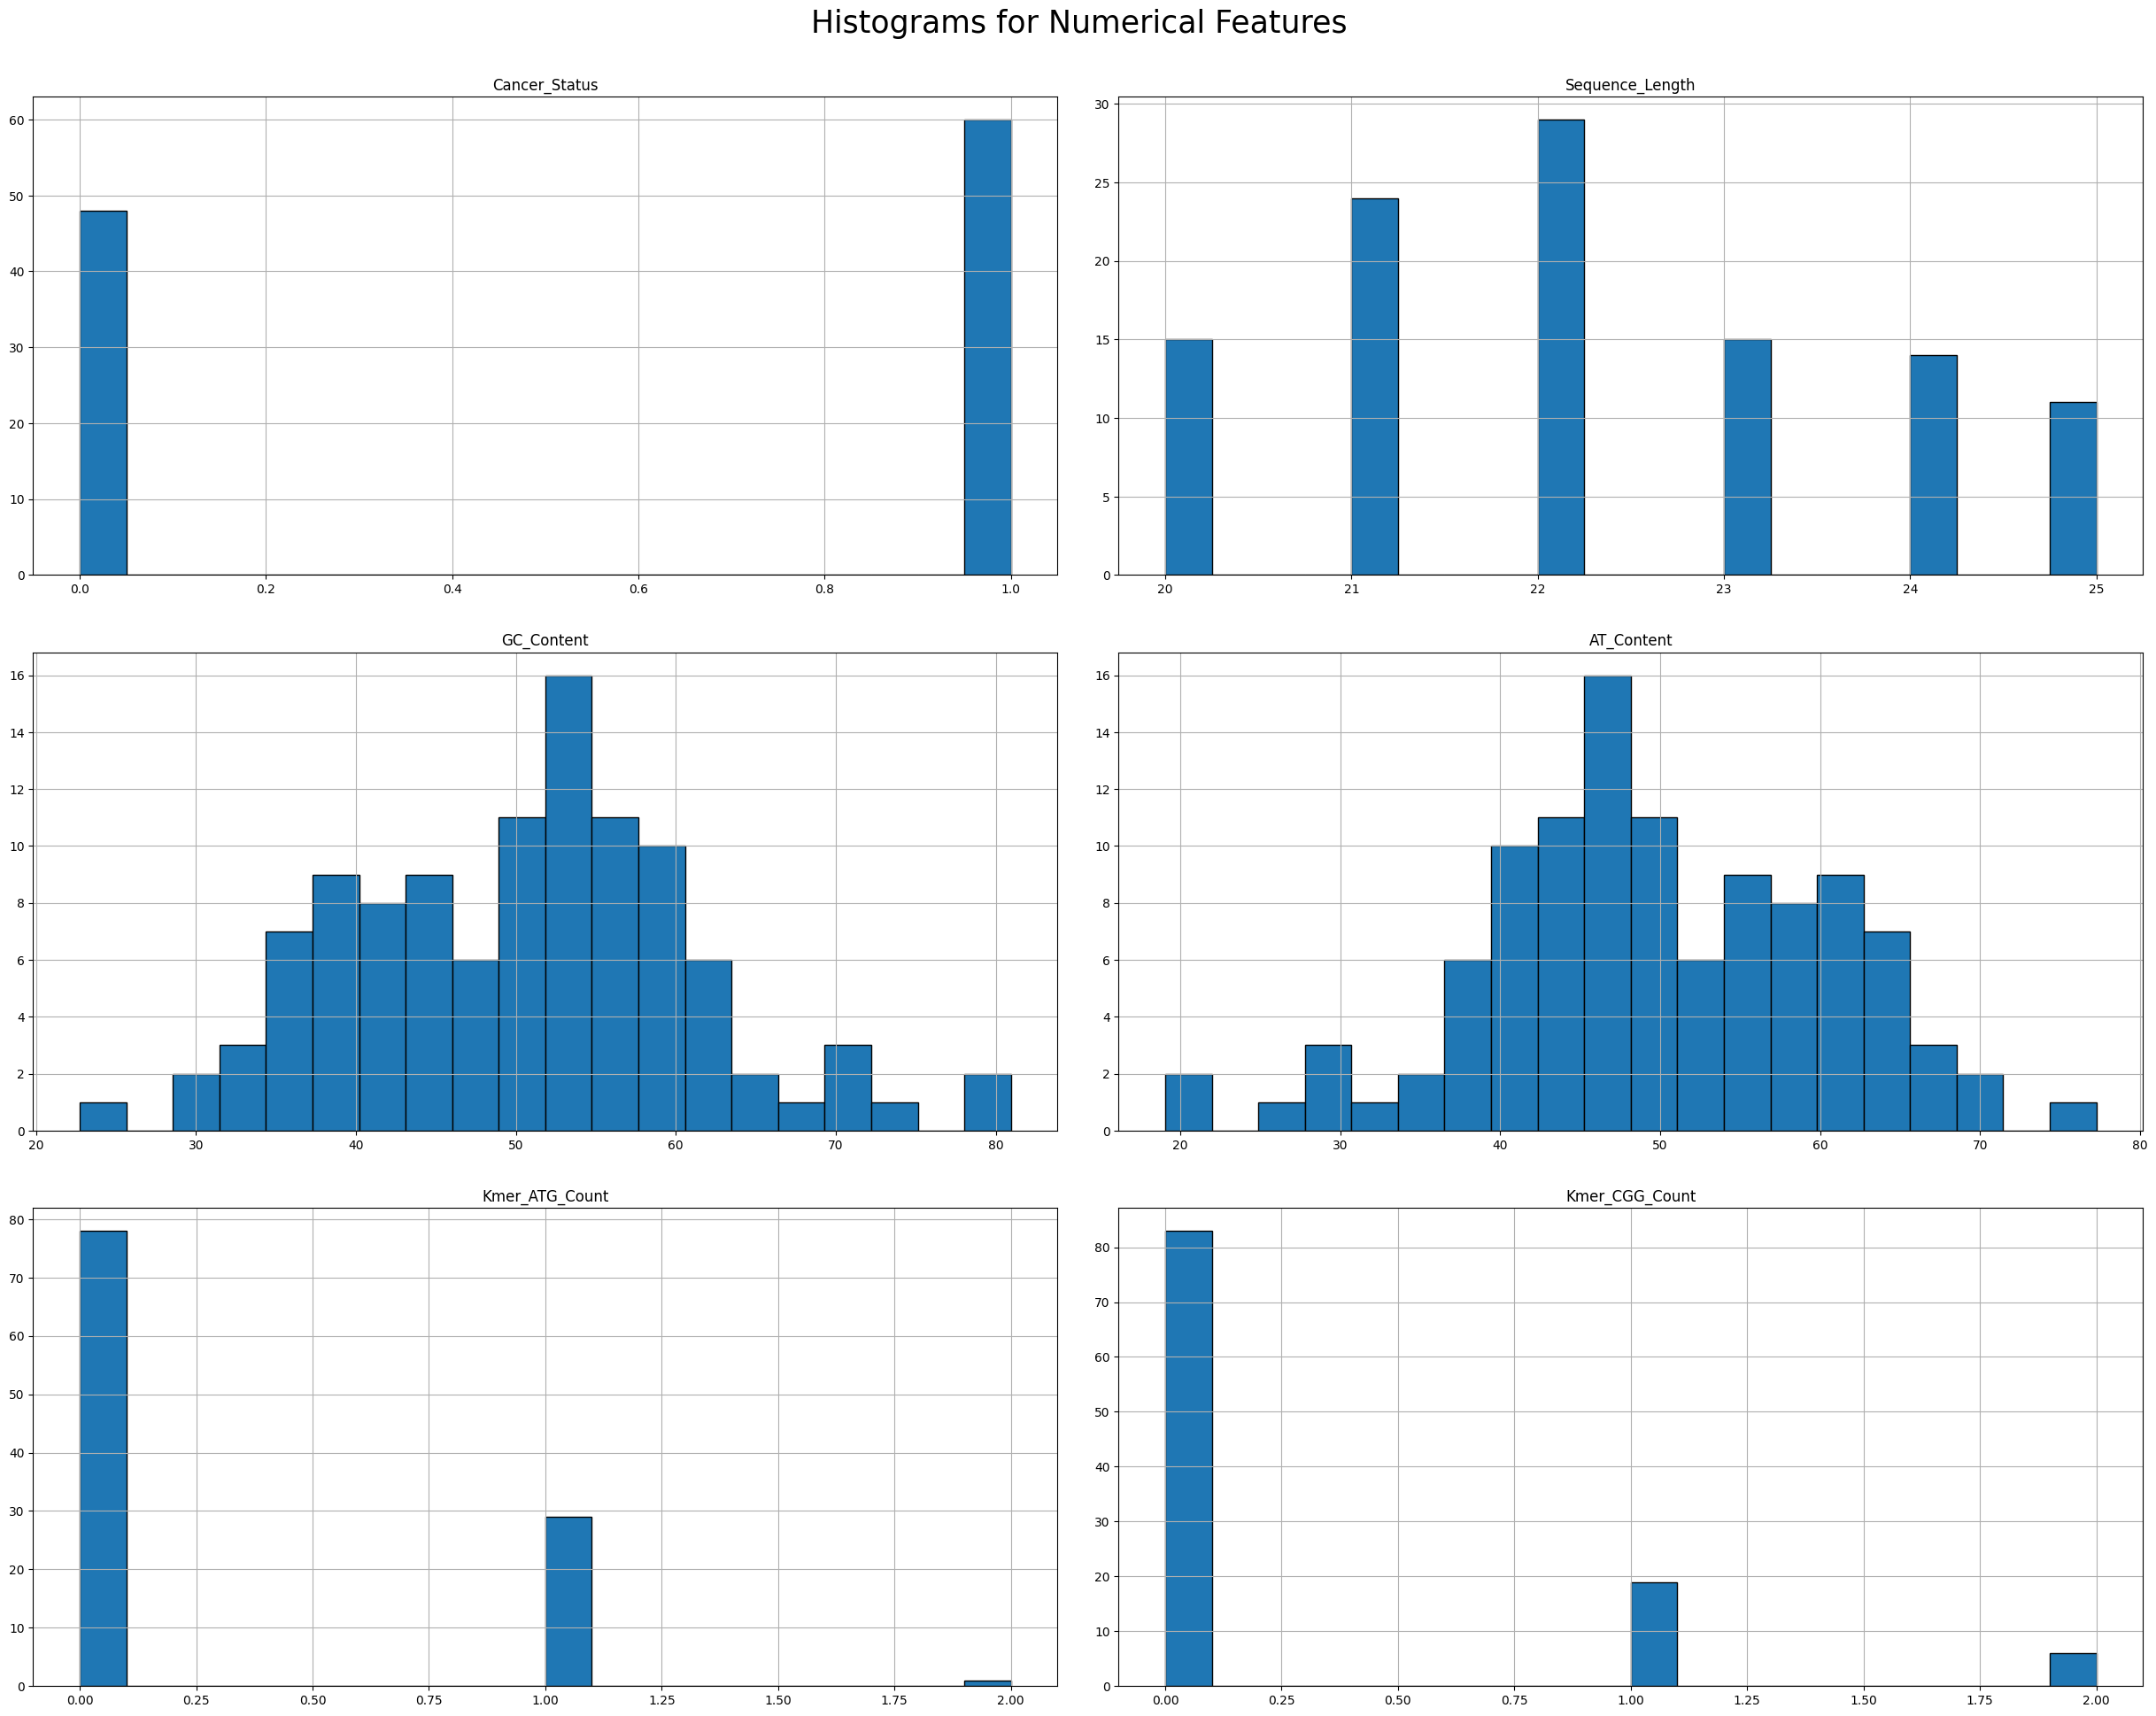

In [37]:
numerical_features = ["Sequence_Length", "GC_Content", "AT_Content",
                     "Kmer_ATG_Count", "Kmer_CGG_Count"]
numerical_features = df.select_dtypes(include=['float64','int64'])
numerical_features.hist(figsize=(25, 20), bins=20, edgecolor='black')
plt.suptitle('Histograms for Numerical Features', fontsize=25)
plt.tight_layout(pad=3.0)

plt.show()

In [38]:
print(df.head(10))

  Sample_ID              DNA_Sequence  Cancer_Status  Sequence_Length  \
0        S1    ATGCGTACGTTAGCCTAGGCTA              0               22   
1        S2    TTAGCGATCGGATCGATCGTAA              1               22   
2        S3     CGATGCTAGCTAGCGTAGCTA              1               21   
3        S4     GCTAGCTAGATCGATGCTAGC              0               21   
4        S5    ATCGATGCTAGCTAGCGATCGA              1               22   
5        S6    TAGCTAGCTAGCGTACGATCAG              0               22   
6        S7    GCGTAGCTAGCTAGCATCGTAC              0               22   
7        S8     CTAGCTAGCATCGATGCTAGC              1               21   
8        S9  CAACAACGGGGCCGCCGGAACATT              0               24   
9       S10      AACCCCATAGCCTCCATTCT              1               20   

   GC_Content  AT_Content  Kmer_ATG_Count  Kmer_CGG_Count  
0       50.00       50.00               1               0  
1       45.45       54.55               0               1  
2       52.38   

# Encoding DNA Sequence





In [39]:
import io

# Define a function for k-mer counting.
def count_kmers(sequence, k):
    """
    Counts k-mers in a DNA sequence.
    """
    counts = {}
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        counts[kmer] = counts.get(kmer, 0) + 1
    return counts

# Apply the k-mer counting to the 'DNA_Sequence' column.
kmer_counts = df['DNA_Sequence'].apply(lambda x: count_kmers(x, 3))

# Convert the k-mer counts Series to a DataFrame.
kmer_df = pd.DataFrame(kmer_counts.tolist()).fillna(0).astype(int)

# Join the k-mer counts with the original DataFrame.
df_encoded = pd.concat([df, kmer_df], axis=1)
df = df_encoded
df = df.drop(columns=["DNA_Sequence"])
df = df.drop(columns=["Sample_ID"])
print(df)

     Cancer_Status  Sequence_Length  GC_Content  AT_Content  Kmer_ATG_Count  \
0                0               22       50.00       50.00               1   
1                1               22       45.45       54.55               0   
2                1               21       52.38       47.62               1   
3                0               21       52.38       47.62               1   
4                1               22       50.00       50.00               1   
..             ...              ...         ...         ...             ...   
103              1               21       52.38       47.62               0   
104              0               22       36.36       63.64               0   
105              0               24       33.33       66.67               1   
106              0               22       22.73       77.27               0   
107              0               20       50.00       50.00               0   

     Kmer_CGG_Count  ATG  TGC  GCG  CGT  ...  GTC  

In [40]:
import pandas as pd

# Suppose your dataset is df
missing_per_column = df.isnull().sum()
print(missing_per_column)

Cancer_Status      0
Sequence_Length    0
GC_Content         0
AT_Content         0
Kmer_ATG_Count     0
                  ..
CAC                0
TTT                0
TTG                0
TGA                0
AAG                0
Length: 70, dtype: int64


In [56]:
from sklearn.preprocessing import MinMaxScaler
import io
cols_to_join = df.columns[5:70]

# Create new column with concatenated sequences (converted to string)
df["Dna_sequence_encoded"] = df[cols_to_join].astype(str).agg("".join, axis=1)

# Show the first few rows of the new column
df[["Dna_sequence_encoded"]].head()
df = df.drop(df.columns[5:70], axis=1)
cols_to_scale = df.columns[0:4]
scaler = MinMaxScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.info()
print(df.head(10))
# kmer_columns = df.columns.tolist()[6:]
# target = df['Cancer_Status']

# features_to_scale = ["Sequence_Length", "GC_Content", "AT_Content",
#                      "Kmer_ATG_Count", "Kmer_CGG_Count"] + kmer_columns
# scaler = MinMaxScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[features_to_scale]),
#                          columns=features_to_scale,
#                          index=df.index)
# df[features_to_scale] = df_scaled
# df = df_scaled
# df["Cancer_Status"] = target
# print(df)

# df['AlcoholIntake'] = df['AlcoholIntake'].fillna(0)
# print(df.head(10))

# df.isna().sum()


df.to_csv("scaled_dataset.csv", index=False)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cancer_Status    108 non-null    float64
 1   Sequence_Length  108 non-null    float64
 2   GC_Content       108 non-null    float64
 3   AT_Content       108 non-null    float64
 4   Kmer_ATG_Count   108 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.3 KB
   Cancer_Status  Sequence_Length  GC_Content  AT_Content  Kmer_ATG_Count
0            0.0              0.4    0.468396    0.531604               1
1            1.0              0.4    0.390244    0.609756               0
2            1.0              0.2    0.509275    0.490725               1
3            0.0              0.2    0.509275    0.490725               1
4            1.0              0.4    0.468396    0.531604               1
5            0.0              0.4    0.468396    0.531604               0
6     

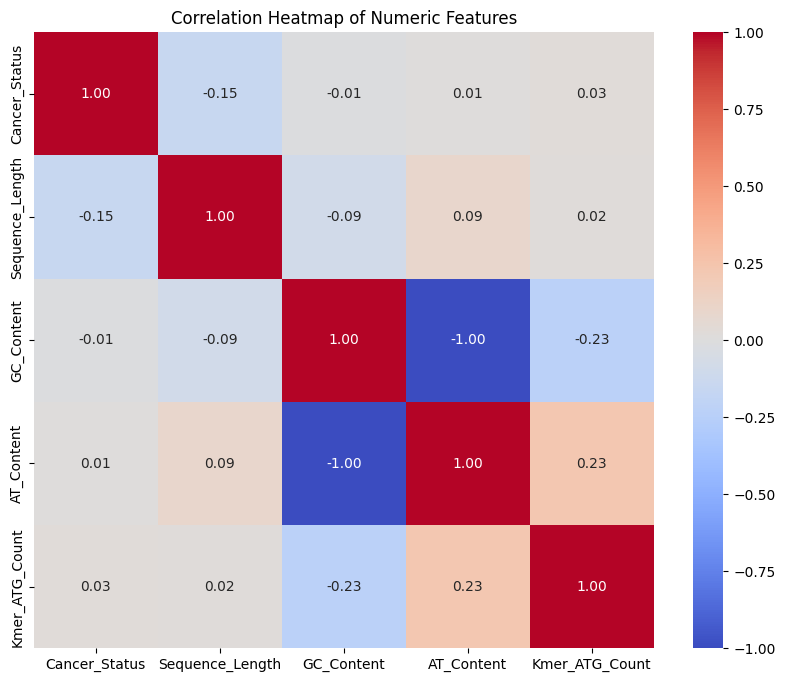

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
df_scaled = pd.read_csv('scaled_dataset.csv')
# Keep only numeric columns
df_numeric = df_scaled.select_dtypes(include=['int64', 'float64'])

# Compute correlation
correlation_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


In [60]:
from sklearn.model_selection import train_test_split
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Separate features (X) and target variable (y)
X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']
print(y.head(10))

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_report_output = classification_report(y_test, y_pred)

# Display evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n", classification_report_output)

0    0.0
1    1.0
2    1.0
3    0.0
4    1.0
5    0.0
6    0.0
7    1.0
8    0.0
9    1.0
Name: Cancer_Status, dtype: float64
Accuracy: 0.45454545454545453
Precision: 0.47619047619047616
Recall: 0.9090909090909091
F1-score: 0.625
ROC-AUC: 0.4214876033057851

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.48      0.91      0.62        11

    accuracy                           0.45        22
   macro avg       0.24      0.45      0.31        22
weighted avg       0.24      0.45      0.31        22



In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred = dt_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n", classification_report_output)
print(report)

# Optional: Cross-validation
cv_scores = cross_val_score(dt_model, X, y, cv=5)
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Accuracy: 0.4090909090909091
Precision: 0.47619047619047616
Recall: 0.9090909090909091
F1-score: 0.625
ROC-AUC: 0.4214876033057851

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.48      0.91      0.62        11

    accuracy                           0.45        22
   macro avg       0.24      0.45      0.31        22
weighted avg       0.24      0.45      0.31        22

              precision    recall  f1-score   support

         0.0       0.33      0.30      0.32        10
         1.0       0.46      0.50      0.48        12

    accuracy                           0.41        22
   macro avg       0.40      0.40      0.40        22
weighted avg       0.40      0.41      0.41        22

5-Fold CV Accuracy: 0.5385 ± 0.1166


In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,        # number of boosting rounds (trees)
    learning_rate=0.1,       # step size shrinkage
    max_depth=5,             # depth of each tree
    subsample=0.8,           # random sampling of training data
    colsample_bytree=0.8,    # random sampling of features
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"    # avoid warning about label encoder
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n", classification_report_output)
print(report)

# Optional: Cross-validation
cv_scores = cross_val_score(xgb_model, X, y, cv=5)
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.45454545454545453
Precision: 0.47619047619047616
Recall: 0.9090909090909091
F1-score: 0.625
ROC-AUC: 0.4214876033057851

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.48      0.91      0.62        11

    accuracy                           0.45        22
   macro avg       0.24      0.45      0.31        22
weighted avg       0.24      0.45      0.31        22

              precision    recall  f1-score   support

         0.0       0.40      0.40      0.40        10
         1.0       0.50      0.50      0.50        12

    accuracy                           0.45        22
   macro avg       0.45      0.45      0.45        22
weighted avg       0.45      0.45      0.45        22



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5-Fold CV Accuracy: 0.5381 ± 0.0649


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Clustering

In [64]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']

# Scale features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X)

# Run KMeans clustering with 2 clusters (Cancer vs Healthy)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Encode true labels for comparison
label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(y)

# Evaluate clustering
ari_score = adjusted_rand_score(y_true, cluster_labels)
conf_matrix = confusion_matrix(y_true, cluster_labels)

# Print results
print("Adjusted Rand Index (ARI):", ari_score)
print("\nConfusion Matrix (true labels vs clusters):\n", conf_matrix)

Adjusted Rand Index (ARI): -0.007936234084400124

Confusion Matrix (true labels vs clusters):
 [[22 26]
 [30 30]]


# PCA

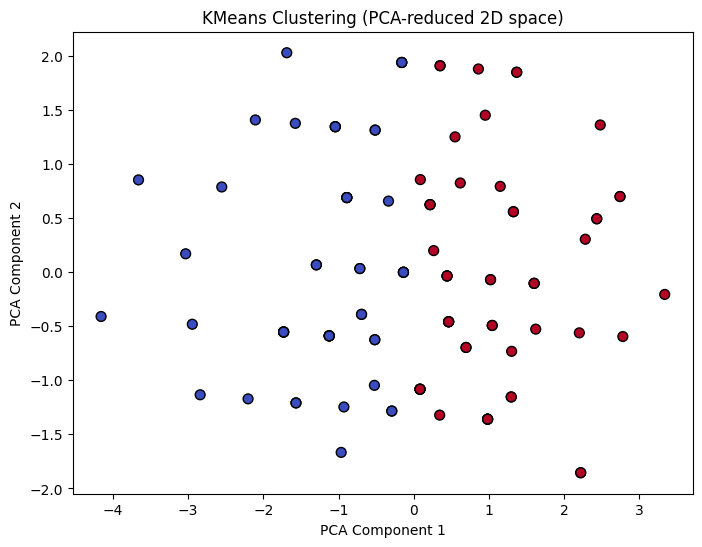

Adjusted Rand Index (ARI): -0.007936234084400124
Normalized Mutual Information (NMI): 0.0012454094197151423
Silhouette Score: 0.2975208338909501

Confusion Matrix (true vs clusters):
 [[22 26]
 [30 30]]


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, confusion_matrix

X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']


# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# True labels
label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(y)

# --- PCA for visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="coolwarm", s=50, edgecolors='k')
plt.title("KMeans Clustering (PCA-reduced 2D space)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# --- Evaluation metrics ---
# External (since we have labels)
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

# Internal (unsupervised)
silhouette = silhouette_score(X_scaled, cluster_labels)

# Confusion matrix after mapping clusters to labels
conf_matrix = confusion_matrix(y_true, cluster_labels)

print("Adjusted Rand Index (ARI):", ari)
print("Normalized Mutual Information (NMI):", nmi)
print("Silhouette Score:", silhouette)
print("\nConfusion Matrix (true vs clusters):\n", conf_matrix)


# Support vector machine

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Features and target
X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']


# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 3: Train SVM model
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train, y_train)

# Step 4: Predictions and evaluation
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

import pandas as pd
report_df = pd.DataFrame(report).T

accuracy, report_df

(0.5454545454545454,
               precision    recall  f1-score    support
 0.0            0.500000  0.133333  0.210526  15.000000
 1.0            0.551724  0.888889  0.680851  18.000000
 accuracy       0.545455  0.545455  0.545455   0.545455
 macro avg      0.525862  0.511111  0.445689  33.000000
 weighted avg   0.528213  0.545455  0.467067  33.000000)

# CNN

In [90]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Load dataset
df = pd.read_csv('cancer_dna_dataset.csv')

# Step 1: Encode DNA Sequences
mapping = {"A":0, "T":1, "C":2, "G":3}

def encode_sequence(seq):
    return [mapping[nt] for nt in seq if nt in mapping]

encoded_sequences = [encode_sequence(seq) for seq in df["DNA_Sequence"]]


# Pad sequences to equal length
max_len = max(len(seq) for seq in encoded_sequences)
X = pad_sequences(encoded_sequences, maxlen=max_len, padding="post")

# One-hot encode nucleotides (A,T,C,G → 4 channels)
X = to_categorical(X, num_classes=4)

# Step 2: Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(df["Cancer_Status"])  # Healthy=0, Cancer=1

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Build 1D CNN
model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(max_len, 4)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=8,
                    validation_data=(X_test, y_test), verbose=1)

# Step 6: Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4767 - loss: 0.7147 - val_accuracy: 0.5000 - val_loss: 0.7175
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5566 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.7018
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6901 - val_accuracy: 0.5000 - val_loss: 0.6974
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5207 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.7011
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5682 - loss: 0.6746 - val_accuracy: 0.5000 - val_loss: 0.7075
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6415 - loss: 0.6547 - val_accuracy: 0.5000 - val_loss: 0.7089
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5974 - loss: 0.6560 - val_accuracy: 0.5000 - val_loss: 0.7140
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6775 - loss: 0.6311 - val_accuracy: 0.4545 - val_loss: 0.70

# MLP

In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('cancer_dna_dataset.csv')

# Select numeric features
features = ["Sequence_Length", "GC_Content", "AT_Content", "Kmer_ATG_Count", "Kmer_CGG_Count"]
X = df[features].values

# Encode target
encoder = LabelEncoder()
y = encoder.fit_transform(df["Cancer_Status"])  # Healthy=0, Cancer=1

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define MLP model
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                    solver='adam', max_iter=500, random_state=42)

# Train
mlp.fit(X_train, y_train)

# Predict
y_pred = mlp.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=encoder.classes_)

acc, report

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(0.5,
 '              precision    recall  f1-score   support\n\n      Cancer       0.50      0.45      0.48        11\n     Healthy       0.50      0.55      0.52        11\n\n    accuracy                           0.50        22\n   macro avg       0.50      0.50      0.50        22\nweighted avg       0.50      0.50      0.50        22\n')

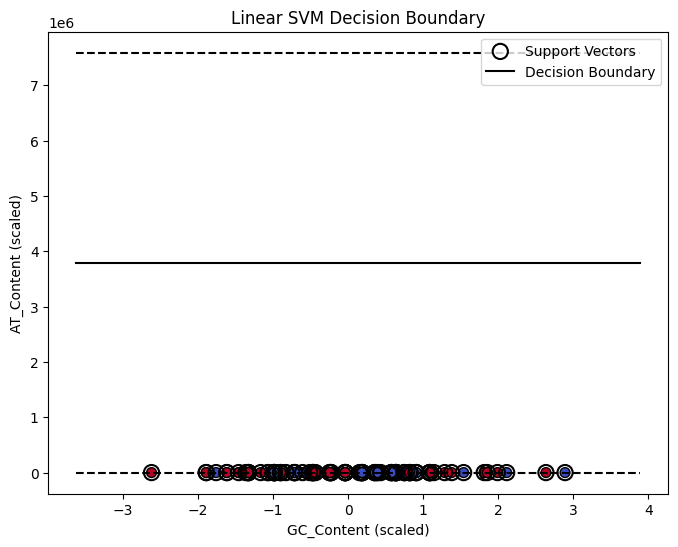

    Sample_ID              DNA_Sequence Cancer_Status  Sequence_Length  \
0          S1    ATGCGTACGTTAGCCTAGGCTA       Healthy               22   
1          S2    TTAGCGATCGGATCGATCGTAA        Cancer               22   
2          S3     CGATGCTAGCTAGCGTAGCTA        Cancer               21   
3          S4     GCTAGCTAGATCGATGCTAGC       Healthy               21   
4          S5    ATCGATGCTAGCTAGCGATCGA        Cancer               22   
..        ...                       ...           ...              ...   
103      S104     TGAGGGAACACTACGGAACAG        Cancer               21   
104      S105    AAGTGGTGATCGATTCATCTTT       Healthy               22   
105      S106  TTGCTTAAAATGGATAAACCTACG       Healthy               24   
106      S107    CTACATAGTATCTAAATTATAC       Healthy               22   
107      S108      CGTTAAGATTTGACCGGCTG       Healthy               20   

     GC_Content  AT_Content  Kmer_ATG_Count  Kmer_CGG_Count  
0         50.00       50.00               1      

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

# Select two features for visualization
X_vis = df[['GC_Content', 'AT_Content']]
y_vis = df['Cancer_Status']

# Encode labels
label_encoder = LabelEncoder()
y_vis = label_encoder.fit_transform(y_vis)

# Scale features
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Train linear SVM
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_vis_scaled, y_vis)

# Plot data points
plt.figure(figsize=(8,6))
plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, cmap=plt.cm.coolwarm, s=50, edgecolors='k')

# Plot support vectors
plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='k', linewidths=1.5, label="Support Vectors")

# Get line parameters
w = svm_linear.coef_[0]
b = svm_linear.intercept_[0]

# Decision boundary (line)
x_vals = np.linspace(X_vis_scaled[:, 0].min()-1, X_vis_scaled[:, 0].max()+1, 100)
y_vals = -(w[0]/w[1]) * x_vals - b/w[1]

# Margins
margin = 1 / np.linalg.norm(w)
y_vals_down = y_vals - np.sqrt(1 + (w[0]/w[1])**2) * margin
y_vals_up   = y_vals + np.sqrt(1 + (w[0]/w[1])**2) * margin

# Plot lines
plt.plot(x_vals, y_vals, 'k-', label="Decision Boundary")
plt.plot(x_vals, y_vals_down, 'k--')
plt.plot(x_vals, y_vals_up, 'k--')

plt.xlabel("GC_Content (scaled)")
plt.ylabel("AT_Content (scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()
print(df)

In [95]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming df is your DataFrame
# Drop non-feature columns
X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']
# Normalize features for KNNda
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize KNN model
knn_model = KNeighborsClassifier(n_neighbors=5, metric="minkowski")  # k=5, Euclidean distance

# Train model
knn_model.fit(X_train, y_train)

# Predict
y_pred = knn_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

# Optional: Cross-validation
cv_scores = cross_val_score(knn_model, X_scaled, y, cv=5)
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Test Accuracy: 0.5000
Confusion Matrix:
[[3 7]
 [4 8]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.43      0.30      0.35        10
         1.0       0.53      0.67      0.59        12

    accuracy                           0.50        22
   macro avg       0.48      0.48      0.47        22
weighted avg       0.49      0.50      0.48        22

5-Fold CV Accuracy: 0.5840 ± 0.0447


In [99]:
from sklearn.model_selection import GridSearchCV, train_test_split
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Separate features (X) and target variable (y)
X = df_scaled.drop('Cancer_Status', axis=1)
y = df_scaled['Cancer_Status']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Define the hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],          # Inverse of regularization strength
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["liblinear", "saga"],       # solvers that support l1/elasticnet
    "max_iter": [500, 1000, 2000]
}

# Initialize Logistic Regression
logistic_model = LogisticRegression(random_state=42)

# Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="roc_auc",   # optimize for AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Make predictions on the test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")
f1 = f1_score(y_test, y_pred, average="binary")
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_report_output = classification_report(y_test, y_pred)

# Display evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n", classification_report_output)



Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Hyperparameters: {'C': 1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1-score: 0.6666666666666666
ROC-AUC: 0.4669421487603306

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.50      1.00      0.67        11

    accuracy                           0.50        22
   macro avg       0.25      0.50      0.33        22
weighted avg       0.25      0.50      0.33        22



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
225 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solv